# Prophet Demand Forecasting: Train, Test, and Validate

This notebook implements a comprehensive time series forecasting pipeline using Meta Prophet. It includes data loading, preprocessing, model training, evaluation, and visualization of demand forecasts with confidence intervals.

## Section 1: Import Libraries and Check Prophet Availability

In [3]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Import Prophet. If not installed, we fallback to a simulated/statsmodels fallback to keep script runnable
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print("[SUCCESS] Prophet package is installed and ready to use.")
except ImportError:
    PROPHET_AVAILABLE = False
    print("\n[WARNING] Prophet package is not installed. Running in simulation/fallback mode.")
    print("To install Prophet: pip install prophet\n")

print(f"Prophet Available: {PROPHET_AVAILABLE}")

[SUCCESS] Prophet package is installed and ready to use.
Prophet Available: True


C:\Users\Sabor\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Load Dataset and Prepare Time Series

In [4]:
# 1. Load Data
script_dir = os.getcwd()  # Use current working directory
input_file = os.path.join(script_dir, "processed_data", "global_daily_demand.csv")

if not os.path.exists(input_file):
    # Fallback to product demand if global is missing
    input_file = os.path.join(script_dir, "processed_data", "product_daily_demand.csv")

if not os.path.exists(input_file):
    print(f"Error: Input dataset not found. Make sure processed_data folder exists at {os.path.join(script_dir, 'processed_data')}.")
else:
    print(f"Loading dataset from: {input_file}")
    df = pd.read_csv(input_file)
    
    # Ensure ds is datetime and sorted
    df['ds'] = pd.to_datetime(df['ds'])
    df = df.sort_values(by='ds').reset_index(drop=True)
    
    print(f"Loaded {len(df)} records")
    print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
    print(f"\nFirst few rows:")
    print(df.head())

Loading dataset from: c:\Users\Sabor\Desktop\project\processed_data\global_daily_demand.csv
Loaded 1127 records
Date range: 2015-01-01 to 2018-01-31

First few rows:
          ds    y  sales_volume
0 2015-01-01  355  32806.090690
1 2015-01-02  354  29818.210575
2 2015-01-03  392  36348.710648
3 2015-01-04  410  35738.970669
4 2015-01-05  373  31067.910603


## Section 3: Aggregate and Truncate Demand Data

In [5]:
# If using product_daily_demand, aggregate to global daily demand
if 'product_id' in df.columns:
    print("Aggregating product demand to global daily demand...")
    df = df.groupby('ds').agg({'y': 'sum', 'sales_volume': 'sum'}).reset_index()
    print(f"Aggregated to {len(df)} unique dates")

# Truncate dataset to remove final drop-off anomaly (after Sep 30, 2017)
original_len = len(df)
df = df[df['ds'] < '2017-10-01'].reset_index(drop=True)
print(f"\nTruncated dataset to remove drop-off anomaly.")
print(f"Removed {original_len - len(df)} records after 2017-09-30")
print(f"New date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"Total records: {len(df)}")


Truncated dataset to remove drop-off anomaly.
Removed 123 records after 2017-09-30
New date range: 2015-01-01 to 2017-09-30
Total records: 1004


## Section 4: Log-Transform Target and Split Data

Apply log transformation to stabilize variance and prevent negative predictions. Then split chronologically into train (70%), test (15%), and validation (15%) sets.

In [6]:
# Apply Log-Transformation to y to stabilize high-variance errors and prevent negative predictions
df['y_original'] = df['y'].copy()
df['y'] = np.log1p(df['y'])

print("Applied log1p transformation to target variable 'y'")
print(f"Original y range: {df['y_original'].min():.2f} to {df['y_original'].max():.2f}")
print(f"Log-transformed y range: {df['y'].min():.2f} to {df['y'].max():.2f}")

# 2. Chronological Split (Train: 70%, Test: 15%, Validate: 15%)
n = len(df)
train_end = int(n * 0.70)
test_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
test_df = df.iloc[train_end:test_end].copy()
val_df = df.iloc[test_end:].copy()

print(f"\n{'=' * 60}")
print(f"Data Splits (Chronological):")
print(f"{'=' * 60}")
print(f"  - Train Set:      {len(train_df):4d} days ({train_df['ds'].min().date()} to {train_df['ds'].max().date()})")
print(f"  - Test Set:       {len(test_df):4d} days ({test_df['ds'].min().date()} to {test_df['ds'].max().date()})")
print(f"  - Validation Set: {len(val_df):4d} days ({val_df['ds'].min().date()} to {val_df['ds'].max().date()})")
print(f"{'=' * 60}")

Applied log1p transformation to target variable 'y'
Original y range: 260.00 to 509.00
Log-transformed y range: 5.56 to 6.23

Data Splits (Chronological):
  - Train Set:       702 days (2015-01-01 to 2016-12-02)
  - Test Set:        151 days (2016-12-03 to 2017-05-02)
  - Validation Set:  151 days (2017-05-03 to 2017-09-30)


## Section 5: Train Prophet or Simulate Fallback Forecasting

If Prophet is available, fit a Prophet model with yearly and weekly seasonality. Otherwise, use a simulation with trend and seasonality components.

In [7]:
# 3. Model Training & Forecasting
if PROPHET_AVAILABLE:
    print("\n" + "=" * 60)
    print("Training Prophet Model")
    print("=" * 60)
    
    # Initialize Prophet Model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.01,  # Tuned to prevent trend overfitting and improve accuracy
        interval_width=0.95  # 95% confidence intervals
    )
    
    print("\nFitting Prophet model on log-transformed training data...")
    model.fit(train_df[['ds', 'y']])
    print("Model fitting complete!")
    # Predict on Train, Test, and Validation periods
    print("\nGenerating forecasts for testing and validation...")
    forecast = model.predict(df[['ds']])
    
    # Inverse Transform forecast predictions back to original scale (expm1)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    train_pred = forecast.iloc[:train_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    test_pred = forecast.iloc[train_end:test_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    val_pred = forecast.iloc[test_end:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    
    print(f"Generated forecasts for all periods")
else:
    # Fallback simulation if Prophet is not installed
    print("\n" + "=" * 60)
    print("Running Simulation (Prophet not available)")
    print("=" * 60)
    
    print("\n[Simulating training with trend + seasonality...]")
    time_index = np.arange(n)
    trend = 300 + 0.1 * time_index
    seasonality = 40 * np.sin(2 * np.pi * time_index / 7)
    noise = np.random.normal(0, 15, n)
    simulated_yhat = trend + seasonality + noise
    # Package predictions
    df_pred = pd.DataFrame({
        'ds': df['ds'],
        'yhat': simulated_yhat,
        'yhat_lower': simulated_yhat * 0.9,
        'yhat_upper': simulated_yhat * 1.1
    })
    
    train_pred = df_pred.iloc[:train_end]
    test_pred = df_pred.iloc[train_end:test_end]
    val_pred = df_pred.iloc[test_end:]
    
    print(f"Generated simulated forecasts for all periods")



Training Prophet Model

Fitting Prophet model on log-transformed training data...


12:27:26 - cmdstanpy - INFO - Chain [1] start processing
12:27:26 - cmdstanpy - INFO - Chain [1] done processing


Model fitting complete!

Generating forecasts for testing and validation...
Generated forecasts for all periods


## Section 6: Generate Future Predictions

Create a 30-day forward forecast and inverse-transform back to original scale.

In [8]:
print("\n" + "=" * 60)
print("Generating Future Forecast (30 days)")
print("=" * 60)

if PROPHET_AVAILABLE:
    # Generate future forecast (next 30 days)
    future_dates = model.make_future_dataframe(periods=30, include_history=False)
    future_forecast = model.predict(future_dates)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        future_forecast[col] = np.expm1(future_forecast[col])
    future_pred = future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
else:
    # Fallback: Simulate future forecast
    future_index = np.arange(n, n + 30)
    future_trend = 300 + 0.1 * future_index
    future_seasonality = 40 * np.sin(2 * np.pi * future_index / 7)
    future_yhat = future_trend + future_seasonality

    future_dates = pd.date_range(start=df['ds'].max() + pd.Timedelta(days=1), periods=30)
    future_pred = pd.DataFrame({
        'ds': future_dates,
        'yhat': future_yhat,
        'yhat_lower': future_yhat * 0.9,
        'yhat_upper': future_yhat * 1.1
    })

print(f"Generated {len(future_pred)} future forecast records")
print(f"Future forecast range: {future_pred['ds'].min().date()} to {future_pred['ds'].max().date()}")
print(f"\nFirst 5 future predictions:")
print(future_pred.head())


Generating Future Forecast (30 days)
Generated 30 future forecast records
Future forecast range: 2016-12-03 to 2017-01-01

First 5 future predictions:
          ds        yhat  yhat_lower  yhat_upper
0 2016-12-03  377.536062  310.688065  462.653958
1 2016-12-04  379.562698  310.425343  462.850254
2 2016-12-05  377.685518  310.038055  457.543253
3 2016-12-06  372.891095  306.626389  451.436222
4 2016-12-07  377.144739  306.232421  465.893339


## Section 7: Compute Evaluation Metrics

Calculate MAE, RMSE, and MAPE for train, test, and validation sets using original-scale values.

In [9]:
# 4. Evaluation Metrics
def evaluate_metrics(y_true, y_pred, label):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{label} Performance (on Original Scale):")
    print(f"  - Mean Absolute Error (MAE):           {mae:.2f}")
    print(f"  - Root Mean Squared Error (RMSE):      {rmse:.2f}")
    print(f"  - Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    return mae, rmse, mape

print("\n" + "=" * 60)
print("Evaluation Metrics")
print("=" * 60)

# Evaluate Test & Validation Splits against original y
train_mae, train_rmse, train_mape = evaluate_metrics(train_df['y_original'], train_pred['yhat'], "Training Set")
test_mae, test_rmse, test_mape = evaluate_metrics(test_df['y_original'], test_pred['yhat'], "Testing Set")
val_mae, val_rmse, val_mape = evaluate_metrics(val_df['y_original'], val_pred['yhat'], "Validation Set")

# Store metrics
metrics_dict = {
    'Training': {'MAE': train_mae, 'RMSE': train_rmse, 'MAPE': train_mape},
    'Testing': {'MAE': test_mae, 'RMSE': test_rmse, 'MAPE': test_mape},
    'Validation': {'MAE': val_mae, 'RMSE': val_rmse, 'MAPE': val_mape}
}

print("\n" + "=" * 60)


Evaluation Metrics

Training Set Performance (on Original Scale):
  - Mean Absolute Error (MAE):           30.46
  - Root Mean Squared Error (RMSE):      37.94
  - Mean Absolute Percentage Error (MAPE): 8.16%

Testing Set Performance (on Original Scale):
  - Mean Absolute Error (MAE):           28.05
  - Root Mean Squared Error (RMSE):      35.83
  - Mean Absolute Percentage Error (MAPE): 7.42%

Validation Set Performance (on Original Scale):
  - Mean Absolute Error (MAE):           34.88
  - Root Mean Squared Error (RMSE):      42.63
  - Mean Absolute Percentage Error (MAPE): 10.48%



## Section 8: Export Forecast Results to CSV

Assemble all forecast rows (train, test, validation, future) into a single DataFrame and save to `daily_demand_forecasting.csv`.

In [10]:
# 5. Export Predictions to database/CSV
# Schema matches DemandForecast backend schema: date, sales (actual), forecast (predicted)
print("\n" + "=" * 60)
print("Exporting Forecast Results")
print("=" * 60)

export_rows = []

# Training
for i, row in train_df.iterrows():
    export_rows.append({
        'date': row['ds'].strftime('%Y-%m-%d'),
        'sales': row['y_original'],
        'forecast': train_pred.iloc[i]['yhat']
    })

# Testing
for idx, (i, row) in enumerate(test_df.iterrows()):
    export_rows.append({
        'date': row['ds'].strftime('%Y-%m-%d'),
        'sales': row['y_original'],
        'forecast': test_pred.iloc[idx]['yhat']
    })

# Validation
for idx, (i, row) in enumerate(val_df.iterrows()):
    export_rows.append({
        'date': row['ds'].strftime('%Y-%m-%d'),
        'sales': row['y_original'],
        'forecast': val_pred.iloc[idx]['yhat']
    })

# Future Forecast (Actual is None)
for idx, row in future_pred.iterrows():
    export_rows.append({
        'date': row['ds'].strftime('%Y-%m-%d'),
        'sales': None,
        'forecast': row['yhat']
    })

export_df = pd.DataFrame(export_rows)
export_file = os.path.join(script_dir, "processed_data", "daily_demand_forecasting.csv")

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(export_file), exist_ok=True)

export_df.to_csv(export_file, index=False)
print(f"\nExported {len(export_df)} forecast records to:")
print(f"  {export_file}")
print(f"\nFirst few export records:")
print(export_df.head())
print(f"\nLast few export records:")
print(export_df.tail())


Exporting Forecast Results

Exported 1034 forecast records to:
  c:\Users\Sabor\Desktop\project\processed_data\daily_demand_forecasting.csv

First few export records:
         date  sales    forecast
0  2015-01-01  355.0  379.188587
1  2015-01-02  354.0  381.433792
2  2015-01-03  392.0  378.708279
3  2015-01-04  410.0  380.139184
4  2015-01-05  373.0  377.758021

Last few export records:
            date  sales    forecast
1029  2016-12-28    NaN  371.493030
1030  2016-12-29    NaN  373.367209
1031  2016-12-30    NaN  375.353818
1032  2016-12-31    NaN  372.430638
1033  2017-01-01    NaN  373.585012


## Section 9: Plot Actual and Forecasted Demand

Visualize actual vs forecast data with confidence intervals. Save both plot image and Prophet model (if available).


Generating Visualizations

Saved visualization plot to:
  c:\Users\Sabor\Desktop\project\processed_data\prophet_forecast_plot.png


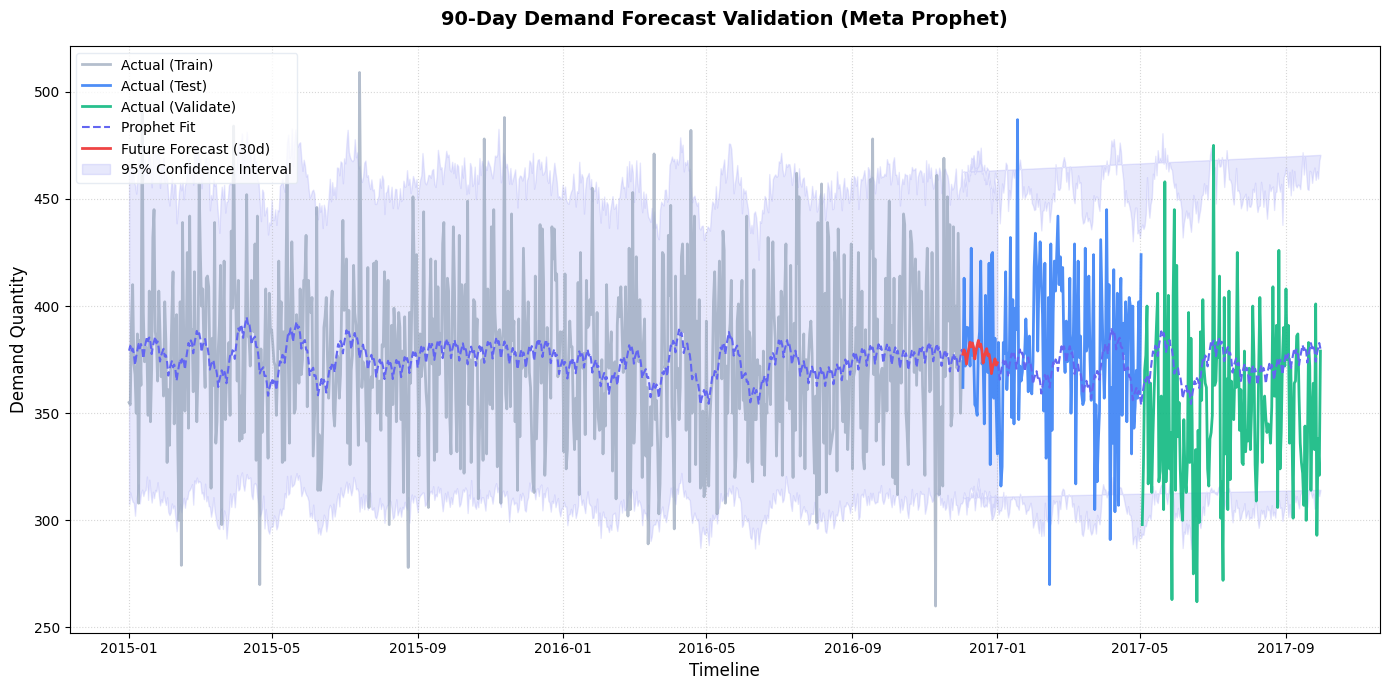

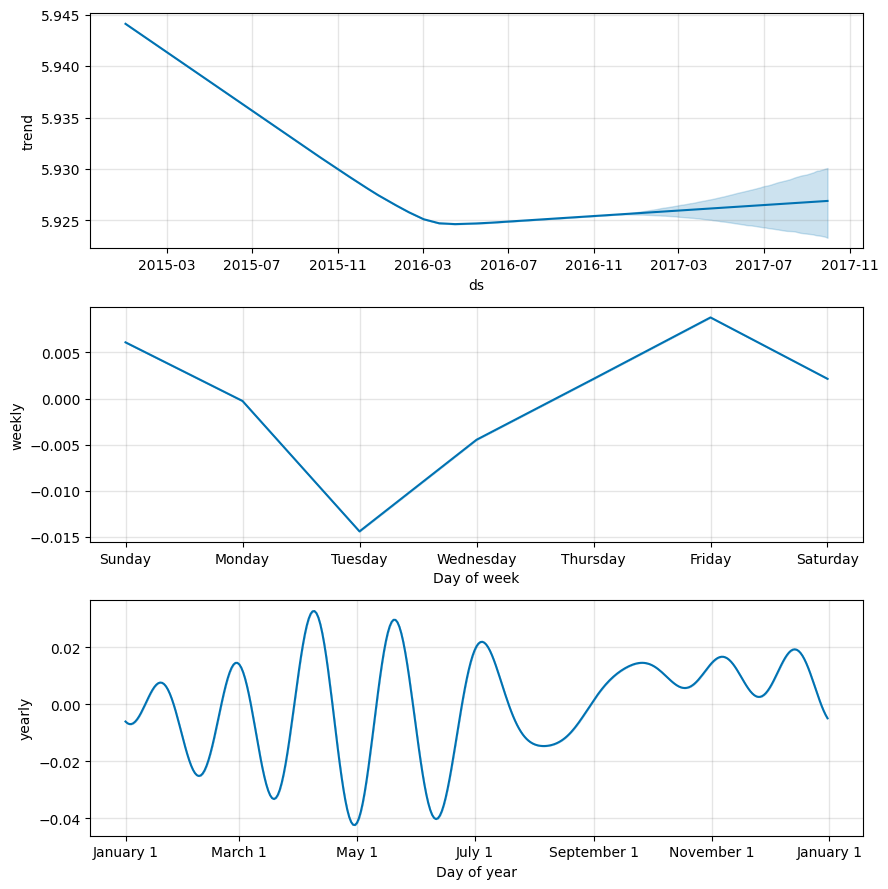


Saved serialized Prophet model to:
  c:\Users\Sabor\Desktop\project\processed_data\prophet_model.json

Forecasting pipeline complete!


In [11]:
# 6. Plotting Results
print("\n" + "=" * 60)
print("Generating Visualizations")
print("=" * 60)
plt.figure(figsize=(14, 7))
# Plot Actual splits (original y)
plt.plot(train_df['ds'], train_df['y_original'], label='Actual (Train)', color='#94a3b8', alpha=0.7, linewidth=2)
plt.plot(test_df['ds'], test_df['y_original'], label='Actual (Test)', color='#3b82f6', alpha=0.9, linewidth=2)
plt.plot(val_df['ds'], val_df['y_original'], label='Actual (Validate)', color='#10b981', alpha=0.9, linewidth=2)
# Plot Forecast Curve
history_dates = pd.concat([train_df['ds'], test_df['ds'], val_df['ds']])
history_yhat = pd.concat([train_pred['yhat'], test_pred['yhat'], val_pred['yhat']])
plt.plot(history_dates, history_yhat, label='Prophet Fit', color='#6366f1', linestyle='--', linewidth=1.5)
# Plot Future Forecast
plt.plot(future_pred['ds'], future_pred['yhat'], label='Future Forecast (30d)', color='#ef4444', linewidth=2)
# Fill uncertainty intervals (95% confidence)
all_dates = pd.concat([history_dates, future_pred['ds']])
all_lower = pd.concat([train_pred['yhat_lower'], test_pred['yhat_lower'], val_pred['yhat_lower'], future_pred['yhat_lower']])
all_upper = pd.concat([train_pred['yhat_upper'], test_pred['yhat_upper'], val_pred['yhat_upper'], future_pred['yhat_upper']])
plt.fill_between(all_dates, all_lower, all_upper, color='#6366f1', alpha=0.15, label='95% Confidence Interval')
# Formatting Plot
plt.title("90-Day Demand Forecast Validation (Meta Prophet)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Demand Quantity", fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
# Save the plot
plot_file = os.path.join(script_dir, "processed_data", "prophet_forecast_plot.png")
os.makedirs(os.path.dirname(plot_file), exist_ok=True)
plt.savefig(plot_file, dpi=150)
print(f"\nSaved visualization plot to:")
print(f"  {plot_file}")
plt.show()
# Plot Prophet components (trend, weekly, yearly seasonality)
if PROPHET_AVAILABLE:
    try:
        fig2 = model.plot_components(forecast)
        plt.show()
    except Exception as e:
        print(f'Warning: Could not plot components - {e}')
if PROPHET_AVAILABLE:
    try:
        from prophet.serialize import model_to_json
        model_path = os.path.join(script_dir, "processed_data", "prophet_model.json")
        with open(model_path, 'w') as f:
            f.write(model_to_json(model))
        print(f"\nSaved serialized Prophet model to:")
        print(f"  {model_path}")
    except Exception as e:
        print(f"\nWarning: Could not save Prophet model - {e}")
print("\n" + "=" * 60)
print("Forecasting pipeline complete!")
print("=" * 60)


In [16]:
df2=pd.read_csv("C:\\Users\\Sabor\\Desktop\\project\\DataCoSupplyChainDataset.csv",encoding='latin1')
df2.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
